# Preparación y análisis del corpus

Este *notebook* cubre las fases previas al entrenamiento del modelo de clasificación de intención.

1. **Carga y filtrado** del dataset CLINC150 al subdominio de cocina (8 intenciones).
2. **Análisis exploratorio (EDA)**: distribución de clases, longitudes, vocabulario y ejemplos representativos.
3. **Construcción del corpus bilingüe**: fusión de particiones y traducción automática al español.
4. **Preprocesamiento y normalización**: expansión de contracciones, lematización, corrección ortográfica, sinónimos y *stopwords*.
5. **Análisis del preprocesamiento**: comparativas antes/después y estadísticas del corpus resultante.
6. **Exportación** de los datos limpios para usar en `PoC_PLN.ipynb`.

**Salidas de este notebook** (guardadas en la carpeta `data/`):
- `data/data_train.csv`, `data/data_test.csv` - datos brutos bilingües
- `data/clean_data_train_en.csv`, `data/clean_data_test_en.csv` - datos preprocesados en inglés
- `data/clean_data_train_es.csv`, `data/clean_data_test_es.csv` - datos preprocesados en español

## Índice

1. [Carga y filtrado de CLINC150](#1-Carga-y-filtrado-de-CLINC150)
2. [Análisis exploratorio del corpus (EDA)](#2-Análisis-exploratorio-del-corpus-EDA)
   - [2.1 Distribución de clases](#21-Distribución-de-clases)
   - [2.2 Análisis de longitud de textos](#22-Análisis-de-longitud-de-textos)
   - [2.3 Ejemplos representativos por clase](#23-Ejemplos-representativos-por-clase)
   - [2.4 Análisis de vocabulario](#24-Análisis-de-vocabulario)
3. [Construcción del corpus bilingüe](#3-Construcción-del-corpus-bilingüe)
   - [3.1 Fusión de particiones y reetiquetado](#31-Fusión-de-particiones-y-reetiquetado)
   - [3.2 Traducción automática al español](#32-Traducción-automática-al-español)
4. [*Pipeline* de preprocesamiento y normalización](#4-Pipeline-de-preprocesamiento-y-normalización)
   - [4.1 Descripción del flujo](#41-Descripción-del-flujo)
   - [4.2 Aplicación del preprocesamiento al corpus](#42-Aplicación-del-preprocesamiento-al-corpus)
5. [Análisis del preprocesamiento](#5-Análisis-del-preprocesamiento)
   - [5.1 Comparativa antes/después](#51-Comparativa-antesdespués)
   - [5.2 Vocabulario resultante](#52-Vocabulario-resultante)
6. [Exportación de datos limpios](#6-Exportación-de-datos-limpios)

## 1. Carga y filtrado de CLINC150

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

In [ ]:
print('Cargando CLINC150 (configuración plus)...')
dataset = load_dataset('clinc_oos', 'plus')
print(dataset)

Cargando CLINC150 (configuración plus)...
DatasetDict({
    train: Dataset({
        features: ['text', 'intent'],
        num_rows: 15250
    })
    validation: Dataset({
        features: ['text', 'intent'],
        num_rows: 3100
    })
    test: Dataset({
        features: ['text', 'intent'],
        num_rows: 5500
    })
})


CLINC150 viene partido en tres conjuntos. Dado el volumen reducido tras el filtrado al dominio de cocina (150 ejemplos por clase en total), fusionamos `train` y `validation` como conjunto de entrenamiento y reservamos `test` para la evaluación final.

In [ ]:
intent_names = dataset['train'].features['intent'].names

# Las 8 intenciones del dominio de cocina disponibles en CLINC150
COOKING_INTENTS = [
    'meal_suggestion',
    'recipe',
    'ingredients_list',
    'ingredient_substitution',
    'nutrition_info',
    'calories',
    'cook_time',
    'food_last',
]

# Convertir a DataFrame y añadir nombre de intención
df_train = dataset['train'].to_pandas()
df_val   = dataset['validation'].to_pandas()
df_test  = dataset['test'].to_pandas()

for df in [df_train, df_val, df_test]:
    df['intent_name'] = df['intent'].apply(lambda x: intent_names[x])

# Filtrar al dominio de cocina
cooking_train = df_train[df_train['intent_name'].isin(COOKING_INTENTS)].copy()
cooking_val   = df_val[df_val['intent_name'].isin(COOKING_INTENTS)].copy()
cooking_test  = df_test[df_test['intent_name'].isin(COOKING_INTENTS)].copy()

# Mostrar la cantidad de registros antes y después del filtro
print(f'Train (original): {len(df_train)} -> cocina: {len(cooking_train)}')
print(f'Val   (original): {len(df_val)} -> cocina: {len(cooking_val)}')
print(f'Test  (original): {len(df_test)} -> cocina: {len(cooking_test)}')

Train (original): 15250 -> cocina: 800
Val   (original): 3100 -> cocina: 160
Test  (original): 5500 -> cocina: 240


## 2. Análisis exploratorio del corpus (EDA)

### 2.1 Distribución de clases

In [ ]:
def check_balance(datasets_dict):
    counts = []
    for name, df in datasets_dict.items():
        count_df = df['intent_name'].value_counts().to_frame()
        count_df.columns = [name]
        counts.append(count_df)

    summary_df = pd.concat(counts, axis=1).fillna(0).astype(int)
    summary_df['Total'] = summary_df.sum(axis=1)
    return summary_df.sort_values('Total', ascending=False)

balance_df = check_balance({
    'Train': cooking_train,
    'Val': cooking_val,
    'Test': cooking_test
})

print(balance_df)

                         Train  Val  Test  Total
intent_name                                     
nutrition_info             100   20    30    150
food_last                  100   20    30    150
cook_time                  100   20    30    150
ingredient_substitution    100   20    30    150
calories                   100   20    30    150
ingredients_list           100   20    30    150
meal_suggestion            100   20    30    150
recipe                     100   20    30    150


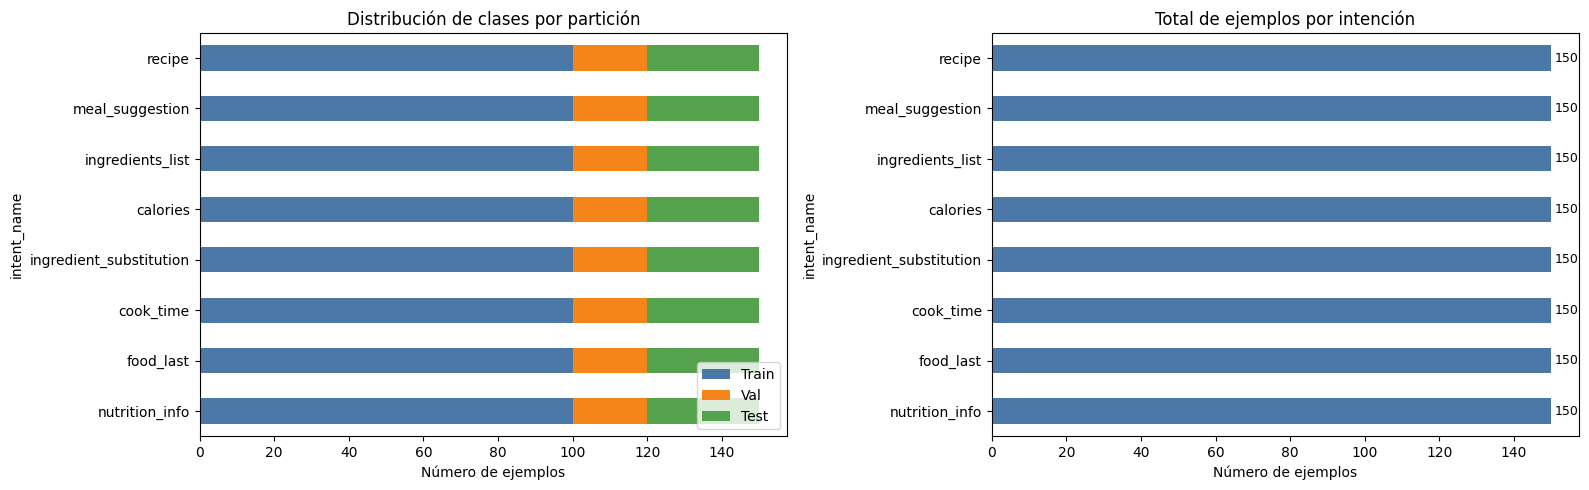


Clases: 8 intenciones perfectamente balanceadas.


In [ ]:
# Visualización del balanceo
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de barras apiladas por partición
df_plot = balance_df.drop(columns='Total')
df_plot.plot(kind='barh', stacked=True, ax=axes[0],
             color=['#4C78A8', '#F58518', '#54A24B'])
axes[0].set_title('Distribución de clases por partición')
axes[0].set_xlabel('Número de ejemplos')
axes[0].legend(loc='lower right')

# Total por clase
balance_df['Total'].sort_values().plot(kind='barh', ax=axes[1], color='#4C78A8')
axes[1].set_title('Total de ejemplos por intención')
axes[1].set_xlabel('Número de ejemplos')
for i, v in enumerate(balance_df['Total'].sort_values()):
    axes[1].text(v + 1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()
print(f'\nClases: {len(balance_df)} intenciones perfectamente balanceadas.')

Las 8 intenciones presentan un **balance perfecto**: 100 ejemplos en train, 20 en val y 30 en test por clase. Esto permite usar *accuracy* como métrica global sin ajustes de ponderación.

### 2.2 Análisis de longitud de textos

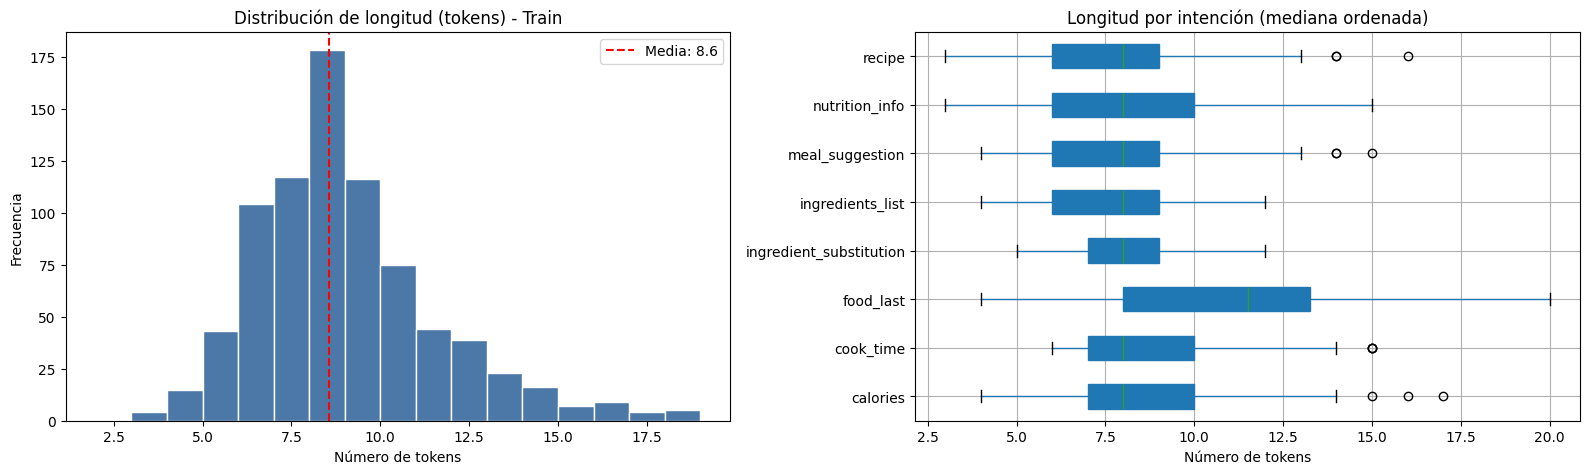

Estadísticas de longitud (tokens):
count    800.00
mean       8.56
std        2.62
min        3.00
25%        7.00
50%        8.00
75%       10.00
max       20.00

Longitud por intención (mediana):
intent_name
calories                    8.0
cook_time                   8.0
ingredient_substitution     8.0
ingredients_list            8.0
nutrition_info              8.0
meal_suggestion             8.0
recipe                      8.0
food_last                  11.5


In [ ]:
# Longitud de los textos en tokens (palabras) para el conjunto de train
cooking_train['n_tokens'] = cooking_train['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma global
axes[0].hist(cooking_train['n_tokens'], bins=range(2, 20), edgecolor='white', color='#4C78A8')
axes[0].set_title('Distribución de longitud (tokens) - Train')
axes[0].set_xlabel('Número de tokens')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(cooking_train['n_tokens'].mean(), color='red', linestyle='--',
                label=f"Media: {cooking_train['n_tokens'].mean():.1f}")
axes[0].legend()

# Boxplot por intención
order = cooking_train.groupby('intent_name')['n_tokens'].median().sort_values().index
cooking_train.boxplot(column='n_tokens', by='intent_name', ax=axes[1],
                      vert=False, patch_artist=True)
axes[1].set_title('Longitud por intención (mediana ordenada)')
axes[1].set_xlabel('Número de tokens')
axes[1].set_ylabel('')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('Estadísticas de longitud (tokens):')
print(cooking_train['n_tokens'].describe().round(2).to_string())
print(f"\nLongitud por intención (mediana):")
print(cooking_train.groupby('intent_name')['n_tokens'].median().sort_values().to_string())

### 2.3 Ejemplos representativos por clase

In [ ]:
N = 3  # Número de ejemplos por intención

for intent in COOKING_INTENTS:
    print(f'\n{'─'*60}')
    print(f'Intención: {intent}')
    print('─'*60)

    sample = cooking_train[cooking_train['intent_name'] == intent].head(N)
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        print(f'  {i}. {row["text"]}')


────────────────────────────────────────────────────────────
Intención: meal_suggestion
────────────────────────────────────────────────────────────
  1. can you give me a french dinner suggestion
  2. suggest a meal from laos to me, please
  3. can you give me a vietnamese meal suggestion

────────────────────────────────────────────────────────────
Intención: recipe
────────────────────────────────────────────────────────────
  1. whats the best way to roast a chicken
  2. how do i make pie crust
  3. find a recipe for german chocolate cake

────────────────────────────────────────────────────────────
Intención: ingredients_list
────────────────────────────────────────────────────────────
  1. what do you put in chicken noodle casserole
  2. what goes into chicken noodle casserole
  3. what do i need to make chicken noodle casserole

────────────────────────────────────────────────────────────
Intención: ingredient_substitution
───────────────────────────────────────────────────────

## 3. Construcción del corpus bilingüe

### 3.1 Fusión de particiones y reetiquetado

In [ ]:
# Reetiquetado compacto (1–8) para las 8 intenciones de cocina
INTENT_MAPPING = {
    'meal_suggestion': 1,
    'recipe': 2,
    'ingredients_list': 3,
    'ingredient_substitution': 4,
    'nutrition_info': 5,
    'calories': 6,
    'cook_time': 7,
    'food_last': 8,
}

# Fusión train + val; test se reserva para evaluación final
dataset_train = pd.concat([cooking_train, cooking_val]).reset_index(drop=True)
dataset_train['intent'] = dataset_train['intent_name'].map(INTENT_MAPPING)

dataset_test = cooking_test.reset_index(drop=True)
dataset_test['intent'] = dataset_test['intent_name'].map(INTENT_MAPPING)

print(f'Train (train+val): {len(dataset_train)} ejemplos')
print(f'Test:              {len(dataset_test)} ejemplos')
print(f'\nDistribución de clases en train:')
print(dataset_train['intent_name'].value_counts().to_string())

Train (train+val): 960 ejemplos
Test:              240 ejemplos

Distribución de clases en train:
intent_name
nutrition_info             120
food_last                  120
cook_time                  120
ingredient_substitution    120
calories                   120
ingredients_list           120
meal_suggestion            120
recipe                     120


### 3.2 Traducción automática al español

CLINC150 es un corpus nativo en inglés. Para soportar consultas en español, generamos una copia traducida de cada ejemplo usando `deep_translator` (Google Translate). Se asume el riesgo de traducciones demasiado literales, inherente a cualquier corpus generado por traducción automática.

In [ ]:
!pip install deep_translator -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.3 MB/s eta 0:00:00


In [ ]:
from deep_translator import GoogleTranslator

translator = GoogleTranslator(source='en', target='es')

def augment_language(df):
    df = df.copy()
    df['language'] = 'en'
    spanish_df = df.copy()
    spanish_df['language'] = 'es'
    print(f'Traduciendo {len(df)} filas...')
    spanish_df['text'] = spanish_df['text'].apply(lambda x: translator.translate(str(x)))
    augmented_df = pd.concat([df, spanish_df], ignore_index=True)
    print('Listo.')
    return augmented_df

final_train = augment_language(dataset_train)
final_test  = augment_language(dataset_test)

Traduciendo 960 filas...
Listo.
Traduciendo 240 filas...
Listo.


In [ ]:
# Verificación: comparar ejemplos EN/ES
print('Ejemplos EN -> ES (test, primeras 5 filas por idioma)\n')
sample_en = final_test[final_test['language'] == 'en'].head(5)
sample_es = final_test[final_test['language'] == 'es'].head(5)

for (_, row_en), (_, row_es) in zip(sample_en.iterrows(), sample_es.iterrows()):
    print(f'[EN] {row_en["text"]}')
    print(f'[ES] {row_es["text"]}')
    print()

Ejemplos EN -> ES (test, primeras 5 filas por idioma)

[EN] tell me nutritional info for brocoli
[ES] dime información nutricional del brócoli

[EN] tell me nutritional info for lettuce
[ES] dime información nutricional de la lechuga

[EN] tell me nutritional info for fish
[ES] dime información nutricional del pescado

[EN] tell me nutritional info for burger
[ES] dime información nutricional de la hamburguesa

[EN] tell me nutritional info for beans
[ES] dime información nutricional de los frijoles



In [ ]:
import os
os.makedirs('data', exist_ok=True)

final_train.to_csv('data/data_train.csv', index=False)
final_test.to_csv('data/data_test.csv', index=False)
print('Guardado: data/data_train.csv y data/data_test.csv')

Guardado: data/data_train.csv y data/data_test.csv


## 4. *Pipeline* de preprocesamiento y normalización

### 4.1 Descripción del flujo

El *pipeline* aplica los siguientes pasos **en orden**.

| Paso | Descripción |
|------|-------------|
| 1. Expansión de contracciones y *slang* | `I'm` -> `I am`; `kiero` -> `quiero` |
| 2. Tokenización y conversión a minúsculas | spaCy: extrae *tokens* en minúscula y sin signos de puntuación |
| 3. Lematización con excepciones | `manzanas` -> `manzana`; `gluten` se protege de lemas incorrectos |
| 4. Corrección ortográfica (solo producción) | pyspellchecker con *whitelist* de términos culinarios |
| 5. Normalización | Eliminar tildes y caracteres raros |
| 6. Filtrado de *stopwords* | Se retienen negaciones y términos clave del dominio |
| 7. Sustitución de sinónimos/regionalismos | `papa` -> `patata`; `palta` -> `aguacate` |

In [2]:
!pip install spacy pyspellchecker lingua-language-detector unidecode contractions -q
!python -m spacy download es_core_news_md -q
!python -m spacy download en_core_web_md -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.3/170.3 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 14.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 59.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠

In [5]:
data_train = pd.read_csv('data/data_train.csv')
data_test  = pd.read_csv('data/data_test.csv')

data_train_es = data_train[data_train['language'] == 'es'].copy()
data_test_es  = data_test[data_test['language'] == 'es'].copy()
data_train_en = data_train[data_train['language'] == 'en'].copy()
data_test_en  = data_test[data_test['language'] == 'en'].copy()

print(f'Train EN: {len(data_train_en)} | Test EN: {len(data_test_en)}')
print(f'Train ES: {len(data_train_es)} | Test ES: {len(data_test_es)}')

Train EN: 960 | Test EN: 240
Train ES: 960 | Test ES: 240


In [6]:
import re
import unidecode
import contractions
import spacy
from spellchecker import SpellChecker
from lingua import Language, LanguageDetectorBuilder

# ── 1. Carga de modelos ──────────────────────────────────────────────
print('Cargando modelos...')
nlp_es = spacy.load('es_core_news_md')
nlp_en = spacy.load('en_core_web_md')
detector = LanguageDetectorBuilder.from_languages(Language.SPANISH, Language.ENGLISH).build()

spell_es = SpellChecker(language='es', distance=1)
spell_en = SpellChecker(language='en', distance=1)

# Palabras técnicas/culinarias que el corrector no debe tocar
spell_es.word_frequency.load_words(
    ['aove', 'thermomix', 'airfryer', 'umami', 'keto', 'dente', 'pizza',
     'sushi', 'confit', 'wok', 'bowl', 'tupper', 'smoothie', 'pancake', 'crepe']
)
spell_en.word_frequency.load_words(
    ['bbq', 'thermomix', 'airfryer', 'umami', 'keto', 'dente', 'ramen']
)

# ── 2. Diccionarios ──────────────────────────────────────────────────
KEEP_ES = {
    'no', 'sin', 'excepto', 'nunca', 'jamas',
    'cuando', 'como', 'cuanto', 'antes', 'despues',
    'hacer', 'estar', 'ser', 'buen', 'mal',
    'gluten', 'lactosa', 'proteina', 'vegano', 'vegana', 'keto', 'umami'
}
KEEP_EN = {
    'no', 'not', 'without', 'never', 'free',
    'when', 'how', 'before', 'after',
    'make', 'good', 'bad',
    'gluten', 'lactose', 'vegan', 'keto', 'umami', 'bbq'
}

STOPWORDS_ES = {unidecode.unidecode(w).lower() for w in nlp_es.Defaults.stop_words} - KEEP_ES
STOPWORDS_EN = {unidecode.unidecode(w).lower() for w in nlp_en.Defaults.stop_words} - KEEP_EN

SLANG_ES = {
    'aser': 'hacer', 'kiero': 'quiero', 'q': 'que', 'xq': 'porque',
    'komo': 'como', 'weno': 'bueno', 'k': 'que', 'x': 'por', 'to': 'todo'
}

LEMMA_EXCEPTIONS_ES = {
    'gluten': 'gluten', 'proteina': 'proteina', 'lactosa': 'lactosa',
    'vegano': 'vegano', 'vegana': 'vegano', 'bizcocho': 'bizcocho',
    'aove': 'aove', 'pizza': 'pizza'
}
LEMMA_EXCEPTIONS_EN = {
    'gluten': 'gluten', 'ramen': 'ramen', 'vegan': 'vegan'
}

SYNONYMS_ES = {
    'papa': 'patata', 'papas': 'patata', 'durazno': 'melocoton',
    'duraznos': 'melocoton', 'palta': 'aguacate', 'paltas': 'aguacate',
    'frutilla': 'fresa', 'frutillas': 'fresa', 'choclo': 'maiz',
    'elote': 'maiz', 'anana': 'pina', 'jugo': 'zumo',
    'banana': 'platano', 'bananas': 'platano',
    'jitomate': 'tomate', 'jitomates': 'tomate',
    'batata': 'boniato', 'batatas': 'boniato',
    'camaron': 'gamba', 'camarones': 'gamba',
    'mani': 'cacahuete', 'manies': 'cacahuete',
    'aji': 'chile', 'ajies': 'chile',
    'pizza': 'piza', 'airfryer': 'freidora de aire'
}
SYNONYMS_EN = {
    'aubergine': 'eggplant', 'aubergines': 'eggplant',
    'courgette': 'zucchini', 'courgettes': 'zucchini',
    'coriander': 'cilantro', 'capsicum': 'bell pepper',
    'rocket': 'arugula',
    'biscuit': 'cookie', 'biscuits': 'cookie',
    'cupcake':  'muffin', 'cupcakes': 'muffin',
    'yoghurt': 'yogurt', 'beetroot': 'beet', 'beetroots': 'beet',
    'prawn': 'shrimp', 'prawns': 'shrimp',
}
BIGRAMS_EN = {'mange tout': 'snow pea'}

# ── 3. Motor de procesamiento ────────────────────────────────────────
def apply_synonyms(text: str, lang: str) -> str:
    if lang == 'en':
        for bigram, canon in BIGRAMS_EN.items():
            text = text.replace(bigram, canon)
    synonyms = SYNONYMS_ES if lang == 'es' else SYNONYMS_EN
    return ' '.join(synonyms.get(w, w) for w in text.split())

def process_text(text: str, lang: str, is_predict: bool = False) -> str:
    if not isinstance(text, str) or not text.strip():
        return ''

    # 1. Contracciones y slang
    if lang == 'en':
        text = contractions.fix(text)
    if lang == 'es':
        for slang, correction in SLANG_ES.items():
            text = re.sub(rf'\b{slang}\b', correction, text, flags=re.IGNORECASE)

    # 2. Configurar herramientas por idioma
    nlp               = nlp_es if lang == 'es' else nlp_en
    stopwords         = STOPWORDS_ES if lang == 'es' else STOPWORDS_EN
    keep_set          = KEEP_ES if lang == 'es' else KEEP_EN
    spell             = spell_es if lang == 'es' else spell_en
    lemma_exceptions  = LEMMA_EXCEPTIONS_ES if lang == 'es' else LEMMA_EXCEPTIONS_EN

    # 3. Tokenización y lematización
    doc = nlp(text)
    clean_tokens = []
    for token in doc:
        if token.is_space or token.is_punct:
            continue
        token_no_accent = unidecode.unidecode(token.text).lower()

        # 4. Lema con excepciones
        if token_no_accent in lemma_exceptions:
            lemma = lemma_exceptions[token_no_accent]
        else:
            lemma = token.lemma_.lower()

        # 5. Corrector ortográfico (solo producción)
        if is_predict and spell.unknown([lemma]):
            corrected = spell.correction(lemma)
            lemma = corrected if corrected else lemma

        # 6. Normalización final
        normalized_lemma = unidecode.unidecode(lemma)

        # 7. Filtrado de stopwords
        if normalized_lemma in keep_set:
            clean_tokens.append(normalized_lemma)
        elif normalized_lemma not in stopwords and len(normalized_lemma) > 1:
            clean_tokens.append(normalized_lemma)

    processed_text = ' '.join(clean_tokens)

    # 8. Sinónimos
    return apply_synonyms(processed_text, lang)

print('Pipeline de preprocesamiento listo.')

Cargando modelos...
Pipeline de preprocesamiento listo.


### 4.2 Aplicación del preprocesamiento al corpus

In [7]:
print('Preprocesando textos en español...')
data_train_es['clean_text'] = data_train_es['text'].apply(
    lambda x: process_text(str(x), lang='es', is_predict=False))
data_test_es['clean_text'] = data_test_es['text'].apply(
    lambda x: process_text(str(x), lang='es', is_predict=False))

print('Preprocesando textos en inglés...')
data_train_en['clean_text'] = data_train_en['text'].apply(
    lambda x: process_text(str(x), lang='en', is_predict=False))
data_test_en['clean_text'] = data_test_en['text'].apply(
    lambda x: process_text(str(x), lang='en', is_predict=False))

print('Preprocesamiento completado')

Preprocesando textos en español...
Preprocesando textos en inglés...
Preprocesamiento completado


## 5. Análisis del preprocesamiento

### 5.1 Comparativa antes/después

In [8]:
# Seleccionamos 3 ejemplos por intención para comparar
print('COMPARATIVA ANTES / DESPUÉS DEL PREPROCESAMIENTO')

COOKING_INTENTS = [
    'meal_suggestion', 'recipe', 'ingredients_list', 'ingredient_substitution',
    'nutrition_info', 'calories', 'cook_time', 'food_last',
]

for lang_label, df in [('EN', data_train_en), ('ES', data_train_es)]:
    print(f'\n{'='*70}')
    print(f'IDIOMA: {lang_label}')
    print('='*70)
    for intent in COOKING_INTENTS:
        subset = df[df['intent_name'] == intent].head(2)
        print(f'\n  [{intent}]')
        for _, row in subset.iterrows():
            print(f'    Original:  {row["text"]}')
            print(f'    Procesado: {row["clean_text"]}')

COMPARATIVA ANTES / DESPUÉS DEL PREPROCESAMIENTO

IDIOMA: EN

  [meal_suggestion]
    Original:  can you give me a french dinner suggestion
    Procesado: french dinner suggestion
    Original:  suggest a meal from laos to me, please
    Procesado: suggest meal laos

  [recipe]
    Original:  whats the best way to roast a chicken
    Procesado: good way roast chicken
    Original:  how do i make pie crust
    Procesado: how make pie crust

  [ingredients_list]
    Original:  what do you put in chicken noodle casserole
    Procesado: chicken noodle casserole
    Original:  what goes into chicken noodle casserole
    Procesado: chicken noodle casserole

  [ingredient_substitution]
    Original:  what about changing the sugar for baking soda
    Procesado: change sugar bake soda
    Original:  can i swap sugar for salt
    Procesado: swap sugar salt

  [nutrition_info]
    Original:  what's the nutritional info for spaghetti
    Procesado: nutritional info spaghetti
    Original:  what's 

[EN] Reducción de longitud tras preprocesamiento:
  Media tokens originales:  8.52
  Media tokens procesados:  4.22
  Reducción media:          49.0%

[ES] Reducción de longitud tras preprocesamiento:
  Media tokens originales:  8.28
  Media tokens procesados:  4.60
  Reducción media:          42.6%



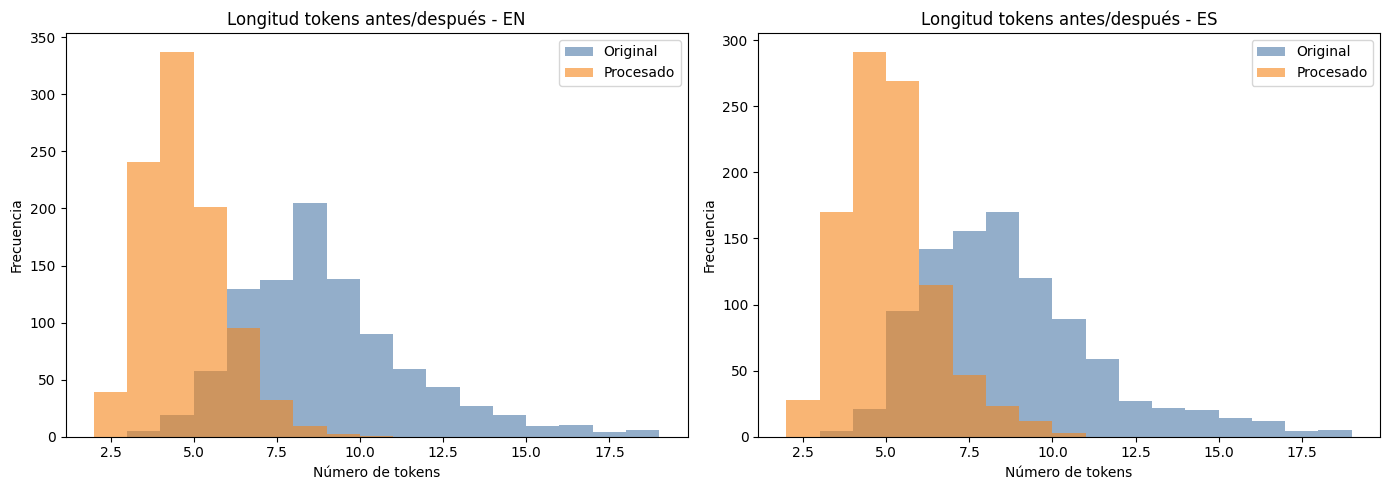

In [11]:
# Reducción de longitud tras el preprocesamiento
for lang_label, train_df, test_df in [
    ('EN', data_train_en, data_test_en),
    ('ES', data_train_es, data_test_es)
]:
    train_df['n_orig']  = train_df['text'].str.split().str.len()
    train_df['n_clean'] = train_df['clean_text'].str.split().str.len()
    train_df['reduction'] = (train_df['n_orig'] - train_df['n_clean']) / train_df['n_orig'] * 100

    print(f'[{lang_label}] Reducción de longitud tras preprocesamiento:')
    print(f'  Media tokens originales:  {train_df["n_orig"].mean():.2f}')
    print(f'  Media tokens procesados:  {train_df["n_clean"].mean():.2f}')
    print(f'  Reducción media:          {train_df["reduction"].mean():.1f}%')
    print()

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (lang_label, df) in zip(axes, [('EN', data_train_en), ('ES', data_train_es)]):
    ax.hist(df['n_orig'], bins=range(2, 20), alpha=0.6, label='Original', color='#4C78A8')
    ax.hist(df['n_clean'], bins=range(2, 20), alpha=0.6, label='Procesado', color='#F58518')
    ax.set_title(f'Longitud tokens antes/después - {lang_label}')
    ax.set_xlabel('Número de tokens')
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.tight_layout()
plt.show()

### 5.2 Vocabulario resultante

In [12]:
from collections import Counter

for lang_label, df in [('EN', data_train_en), ('ES', data_train_es)]:
    vocab_orig  = Counter(' '.join(df['text']).lower().split())
    vocab_clean = Counter(' '.join(df['clean_text']).lower().split())
    print(f'\n[{lang_label}]')
    print(f'  Vocabulario original:  {len(vocab_orig):} tokens únicos')
    print(f'  Vocabulario procesado: {len(vocab_clean):} tokens únicos')
    print(f'  Reducción: {(1 - len(vocab_clean)/len(vocab_orig))*100:.1f}%')
    print(f'  Top 15 tokens procesados: {[t for t, _ in vocab_clean.most_common(15)]}')


[EN]
  Vocabulario original:  855 tokens únicos
  Vocabulario procesado: 628 tokens únicos
  Reducción: 26.5%
  Top 15 tokens procesados: ['how', 'long', 'make', 'need', 'calorie', 'ingredient', 'chicken', 'recipe', 'cook', 'fridge', 'use', 'meal', 'good', 'dinner', 'milk']

[ES]
  Vocabulario original:  1212 tokens únicos
  Vocabulario procesado: 679 tokens únicos
  Reducción: 44.0%
  Top 15 tokens procesados: ['cuanto', 'ser', 'tiempo', 'hacer', 'necesitar', 'caloria', 'ingrediente', 'pollo', 'nutricional', 'receta', 'estar', 'comida', 'deber', 'informacion', 'cocinar']


## 6. Exportación de datos limpios

In [13]:
data_train_es.to_csv('data/clean_data_train_es.csv', index=False)
data_test_es.to_csv('data/clean_data_test_es.csv', index=False)
data_train_en.to_csv('data/clean_data_train_en.csv', index=False)
data_test_en.to_csv('data/clean_data_test_en.csv', index=False)

print('Archivos exportados en data/:')
for fname in ['clean_data_train_es.csv', 'clean_data_test_es.csv',
              'clean_data_train_en.csv', 'clean_data_test_en.csv']:
    print(f'  data/{fname}')
print('\nContinuar en PoC_PLN.ipynb para la clasificación y análisis de resultados.')

Archivos exportados en data/:
  data/clean_data_train_es.csv
  data/clean_data_test_es.csv
  data/clean_data_train_en.csv
  data/clean_data_test_en.csv

Continuar en PoC_PLN.ipynb para la clasificación y análisis de resultados.
